In [25]:
from langchain_core.messages.utils import trim_messages,count_tokens_approximately
from langgraph.graph import StateGraph, START, MessagesState, END
from langgraph.checkpoint.postgres import PostgresSaver
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import RemoveMessage
load_dotenv()

True

In [15]:
llm = ChatGroq(
    model="openai/gpt-oss-120b"
)

In [16]:
MAX_TOKENS = 150

In [27]:
def call_model(state: MessagesState):
    
    # Trim conversation history -> last N messages that fit within the token budget
    messages = trim_messages(
        state["messages"],
        strategy="last",                      
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS
    )

    print('Current Token Count ->', count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content)

    response = llm.invoke(messages)

    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}
    return {}

In [28]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_node("cleanup", delete_old_messages)
builder.add_edge(START, "call_model")
builder.add_edge("call_model", "cleanup")
builder.add_edge("cleanup", END)

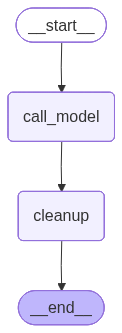

In [29]:
checkpointer = InMemorySaver()
workflow = builder.compile(checkpointer=checkpointer)
workflow

In [31]:
config = {"configurable": {"thread_id": "t1"}}
workflow.invoke({"messages": [{"role": "user", "content": "Hi, I'm Nitish"}]}, config)
workflow.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
workflow.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
workflow.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
workflow.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
workflow.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
workflow.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

Current Token Count -> 46
What is my name
I don’t have any information about your name. If you’d like to share it, feel free to let me know!
Hi, I'm Nitish
Current Token Count -> 75
What is my name
I don’t have any information about your name. If you’d like to share it, feel free to let me know!
Hi, I'm Nitish
Nice to meet you, Nitish! How can I assist you today?
Tell me about LangGraph
Current Token Count -> 11
Now explain checkpointers
Current Token Count -> 9
What is Langchain
Current Token Count -> 11
What is Quantum Mechanics
Current Token Count -> 8
What is Gen AI
Current Token Count -> 8
What is my name


{'messages': [HumanMessage(content='Now explain checkpointers', additional_kwargs={}, response_metadata={}, id='4a83f8eb-b4db-4b89-ad05-82389731eaee'),
  AIMessage(content='## What Is a “Checkpointer”?\n\nA **checkpointer** is a component (usually a piece of software) that periodically saves the state of a running computation so that it can be resumed later without starting from scratch.  \nThe saved state is called a **checkpoint** (or **snapshot**).  \n\nCheckpointers appear in many domains:\n\n| Domain | What the “state” means | Typical use‑cases |\n|--------|------------------------|-------------------|\n| **Machine‑learning training** | Model parameters, optimizer state, epoch/step counters, RNG seeds, data‑loader state | Recover from crashes, continue training after a pause, evaluate intermediate models, share progress across teams |\n| **High‑performance / scientific computing** | Large arrays, MPI ranks, open file handles, simulation time | Fault‑tolerance on super‑computers, c

In [32]:
for item in workflow.get_state({"configurable": {"thread_id": "t1"}}).values['messages']:
    print(item.content)
    print('-'*120)

Now explain checkpointers
------------------------------------------------------------------------------------------------------------------------
## What Is a “Checkpointer”?

A **checkpointer** is a component (usually a piece of software) that periodically saves the state of a running computation so that it can be resumed later without starting from scratch.  
The saved state is called a **checkpoint** (or **snapshot**).  

Checkpointers appear in many domains:

| Domain | What the “state” means | Typical use‑cases |
|--------|------------------------|-------------------|
| **Machine‑learning training** | Model parameters, optimizer state, epoch/step counters, RNG seeds, data‑loader state | Recover from crashes, continue training after a pause, evaluate intermediate models, share progress across teams |
| **High‑performance / scientific computing** | Large arrays, MPI ranks, open file handles, simulation time | Fault‑tolerance on super‑computers, checkpoint‑restart for long simulatio

`trim_messages()` and `RemoveMessage` both help control conversation size, but they work at different levels. `trim_messages()` only limits the messages sent to the LLM during a specific model call, keeping the full conversation history intact in the graph state and checkpoints. This means old messages can still be accessed later, but memory and database storage continue to grow. In contrast, `RemoveMessage` permanently deletes messages from the graph state itself. Once removed, those messages are no longer stored in memory or checkpoints, reducing storage usage and preventing unbounded history growth. In short, **`trim_messages()` is a temporary context-window optimization, whereas `RemoveMessage` is a permanent memory-cleanup mechanism.**
